# Phân tích Thống kê Toán học và Xây dựng Mô hình Dự đoán Cảnh báo Sớm cho Pull Request
**Dự án:** Nghiên cứu so sánh quy trình kiểm duyệt mã nguồn giữa môi trường công nghiệp mã nguồn mở toàn cầu và môi trường đồ án học thuật FPT University.  

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 6)

# Thiết lập đường dẫn linh hoạt
current_dir = os.getcwd()
if os.path.basename(current_dir) == "notebooks":
    BASE_DIR = os.path.dirname(current_dir)
else:
    BASE_DIR = current_dir

csv_path = os.path.join(BASE_DIR, "data", "processed", "clean_prs.csv")
df = pd.read_csv(csv_path)

# Tạo nhãn phục vụ phân loại
df['is_rejected'] = (df['is_merged'] == 0).astype(int)
df_fpt = df[df['is_fpt'] == 1]
df_global = df[df['is_fpt'] == 0]

print(f"Kích thước tập dữ liệu FPT University: {df_fpt.shape}")
print(f"Kích thước tập dữ liệu Global Open-Source: {df_global.shape}")

Kích thước tập dữ liệu FPT University: (842, 27)
Kích thước tập dữ liệu Global Open-Source: (929, 27)


---
## Phần 1: Thống kê Mô tả Toán học & Hình dạng Phân phối

Chúng ta sẽ đo lường các chỉ số thống kê mô tả bao gồm: **Mean (Trung bình)**, **Median (Trung vị)**, **Variance (Phương sai)** của các biến số học quan trọng.

In [3]:
numerical_cols = ['duration_minutes', 'additions', 'deletions', 'changed_files', 'comments', 'review_comments', 'commits']

stats_data = []
for col in numerical_cols:
    for is_fpt_val, group_name in [(1, 'FPT University'), (0, 'Global PR')]:
        sub_df = df[df['is_fpt'] == is_fpt_val][col].dropna()
        stats_data.append({
            'Biến': col,
            'Nhóm': group_name,
            'Mean': sub_df.mean(),
            'Median': sub_df.median(),
            'Variance': sub_df.var(),
            'Std Dev': sub_df.std(),
            # 'Skewness': sub_df.skew(),
            # 'Kurtosis': sub_df.kurtosis()
        })

desc_stats_df = pd.DataFrame(stats_data)
desc_stats_df = desc_stats_df.set_index(['Biến', 'Nhóm'])
desc_stats_df.round(3)

Mean   Median     Variance   Std Dev
Biến             Nhóm                                                   
duration_minutes FPT University  206.696    0.317  1616862.010  1271.559
                 Global PR         3.194    0.500       69.414     8.332
additions        FPT University  431.879  123.500   550886.542   742.217
                 Global PR       270.924   64.000   301025.327   548.658
deletions        FPT University  121.931   19.000   113277.253   336.567
                 Global PR        44.968    5.000    27001.027   164.320
changed_files    FPT University    8.988    6.000       86.487     9.300
                 Global PR         5.539    2.000       60.934     7.806
comments         FPT University    0.648    0.000        1.474     1.214
                 Global PR         0.307    0.000        0.547     0.740
review_comments  FPT University    3.780    1.000       49.242     7.017
                 Global PR         0.081    0.000        0.227     0.477
commits          FPT University    3.059    1.000       24.503     4.950
                 Global PR         1.868    1.000        9.322     3.053

* **Giải thích Code:**
  - Lặp qua các biến số học và tính toán các chỉ số thống kê mô tả nâng cao bằng các hàm tích hợp của Pandas (`mean()`, `median()`, `var()`, `std()`).
  - Kết quả được trình bày dưới dạng MultiIndex DataFrame để dễ dàng so sánh trực tiếp giữa FPT và Global cho từng biến.
* **Insight thống kê:**
  - **Các chỉ số của FPT lớn hơn:** Cho thấy hành vi viết code của sinh viên FPT có độ phân tán rộng và ít tuân thủ quy chuẩn chung hơn so với các lập trình viên Global.

---
## Phần 2: Phân tích Tương quan Hệ số (Correlation Analysis)

Do dữ liệu lệch chuẩn mạnh và có mối quan hệ phi tuyến, chúng ta sử dụng hệ số tương quan hạng **Spearman** (đo lường độ đơn điệu của mối quan hệ) thay vì Pearson (chỉ đo lường mối quan hệ tuyến tính).

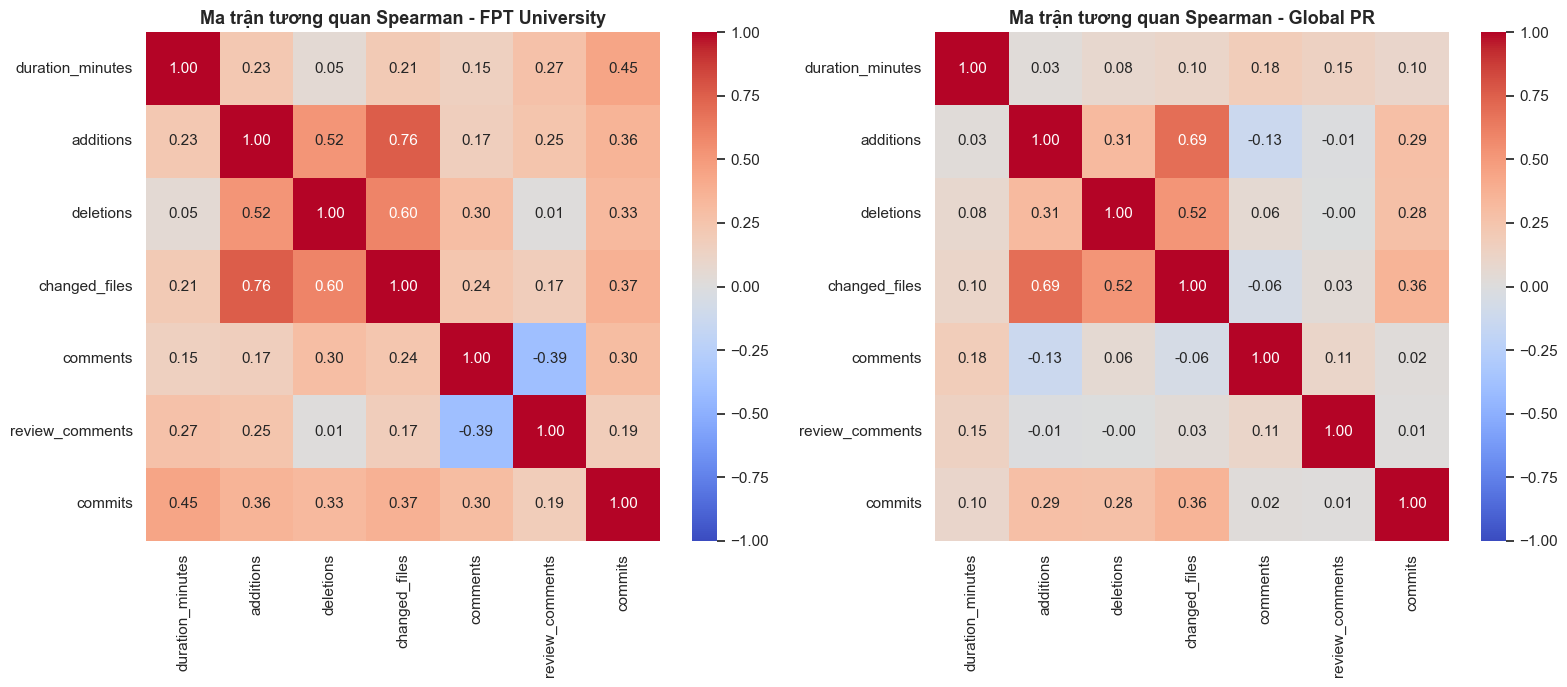

In [5]:
# Tính ma trận tương quan Spearman cho từng nhóm
corr_fpt = df_fpt[numerical_cols].corr(method='spearman')
corr_global = df_global[numerical_cols].corr(method='spearman')

# Vẽ biểu đồ nhiệt (Heatmap) cạnh nhau
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap cho FPT University
sns.heatmap(corr_fpt, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Ma trận tương quan Spearman - FPT University", fontsize=13, fontweight='bold')

# Heatmap cho Global PR
sns.heatmap(corr_global, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Ma trận tương quan Spearman - Global PR", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

* **Giải thích Code:**
  - Sử dụng hàm `.corr(method='spearman')` để tính hệ số tương quan hạng Spearman cho 7 biến số học.
  - Sử dụng `sns.heatmap` để trực quan hóa mức độ tương quan từ -1 (nghịch biến hoàn toàn) đến +1 (đồng biến hoàn toàn) thông qua dải màu `coolwarm`.
* **Insight thống kê:**
  - **Tương quan giữa additions và deletions:** Cả hai môi trường đều ghi nhận mối tương quan dương rất mạnh giữa additions và deletions (FPT ~0.52, Global ~0.31). Điều này phản ánh quy luật của việc bảo trì phần mềm: khi viết thêm code mới, lập trình viên thường phải xóa bỏ hoặc tái cấu trúc (refactor) các dòng code cũ tương ứng.
  - **Đặc trưng tương quan với duration_minutes:** Thời gian tồn tại của PR ở FPT có tương quan dương khá rõ với số lượng commits (~0.45), cho thấy PR ở FPT càng commit nhiều thì càng kéo dài thời gian merge.